<a href="https://colab.research.google.com/github/tauqeer-jetcom/ML_PROJECTS_1-61023748031/blob/main/Support_Vector_Machine_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("train1.data")
df

,0.90026,0.16558,1
0,-0.537720,-0.153010,0
1,0.213690,0.031024,1
2,-0.028035,-0.332100,0
3,0.782600,-0.134190,1
4,0.524190,-0.548100,0
...,...,...,...
94,0.322890,-0.618230,0
95,-0.431180,0.687740,1
96,-0.061551,-0.652200,0
97,-0.870440,-0.658410,0


In [3]:
df.size

297

In [4]:
df.columns

Index(['0.90026', '0.16558', '1'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   0.90026  99 non-null     float64
 1   0.16558  99 non-null     float64
 2   1        99 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 2.4 KB


In [6]:
df.describe()

,0.90026,0.16558,1
count,99.000000,99.000000,99.000000
mean,0.048620,-0.071892,0.464646
std,0.559887,0.560306,0.501287
min,-0.980280,-0.974270,0.000000
25%,-0.411550,-0.560085,0.000000
50%,0.050305,-0.097150,0.000000
75%,0.554030,0.366445,1.000000
max,0.976670,0.988590,1.000000


In [7]:
df = df.rename(columns={'0.90026': 'feature_1', '0.16558': 'feature_2', '1': 'target'})
display(df.head())

,feature_1,feature_2,target
0,-0.537720,-0.153010,0
1,0.213690,0.031024,1
2,-0.028035,-0.332100,0
3,0.782600,-0.134190,1
4,0.524190,-0.548100,0


In [8]:
df.isnull().sum()

,0
feature_1,0
feature_2,0
target,0


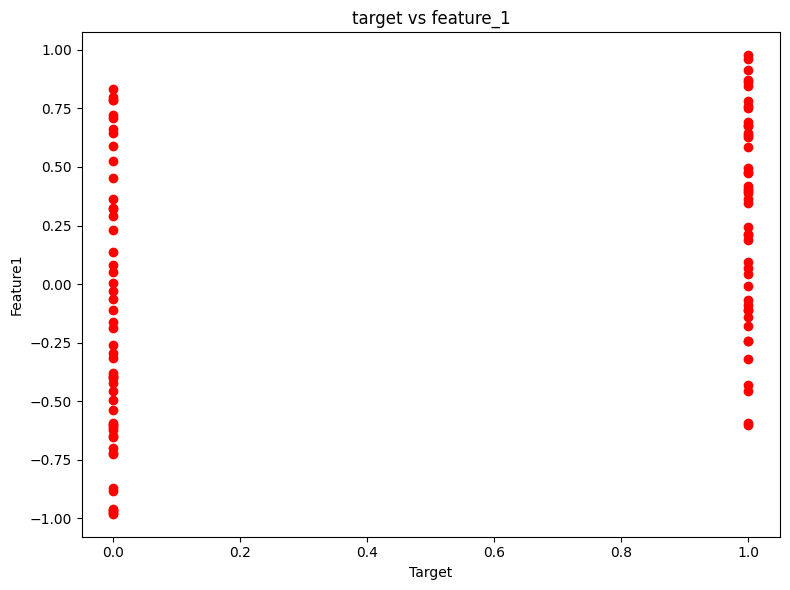

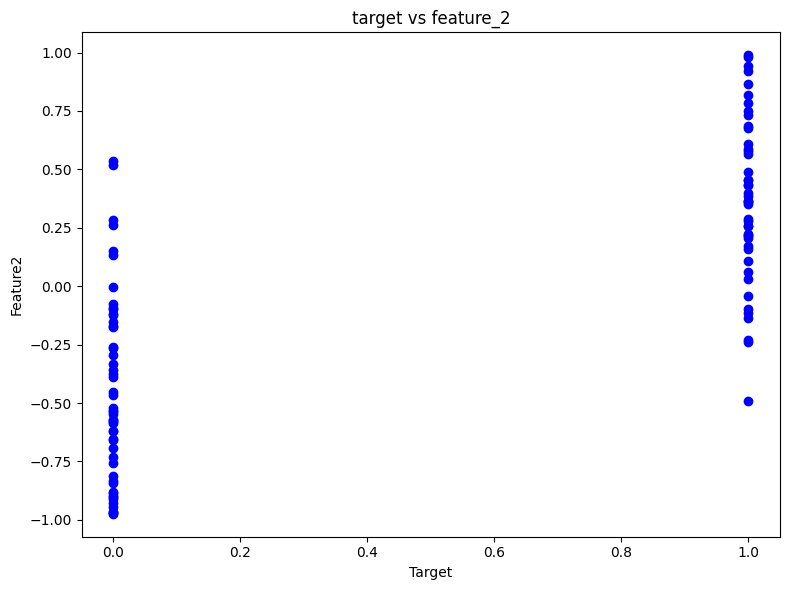

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
plt.scatter("target","feature_1",data=df,color="red")
plt.title("target vs feature_1")
plt.xlabel("Target")
plt.ylabel("Feature1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter("target","feature_2",data=df,color="blue")
plt.title("target vs feature_2")
plt.xlabel("Target")
plt.ylabel("Feature2")
plt.tight_layout()

plt.show()

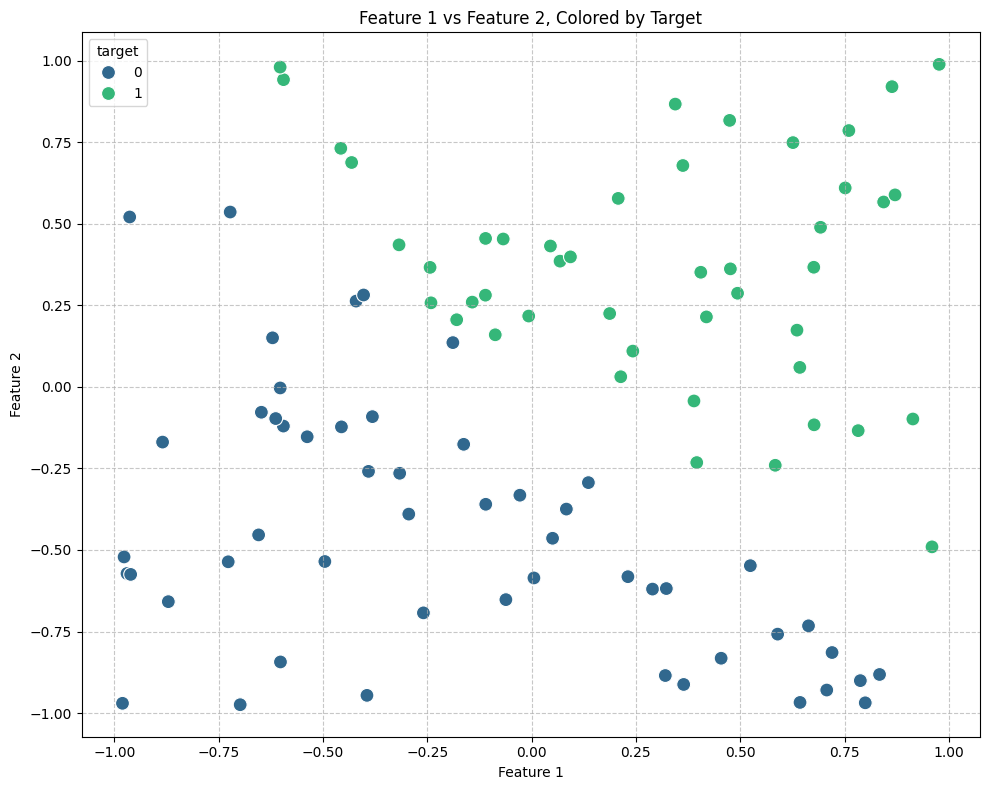

In [10]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='feature_1', y='feature_2', hue='target', data=df, palette='viridis', s=100)
plt.title('Feature 1 vs Feature 2, Colored by Target')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df[['feature_1','feature_2']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear',C=1.0) # Corrected 'kernal' to 'kernel' and 'c' to 'C'
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy}")

conf_matrix = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(conf_matrix)

class_report = classification_report(y_test,y_pred)
print("Classification Report:")
print(class_report)
#

Accuracy: 1.0
Confusion Matrix:
[[12  0]
 [ 0  8]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


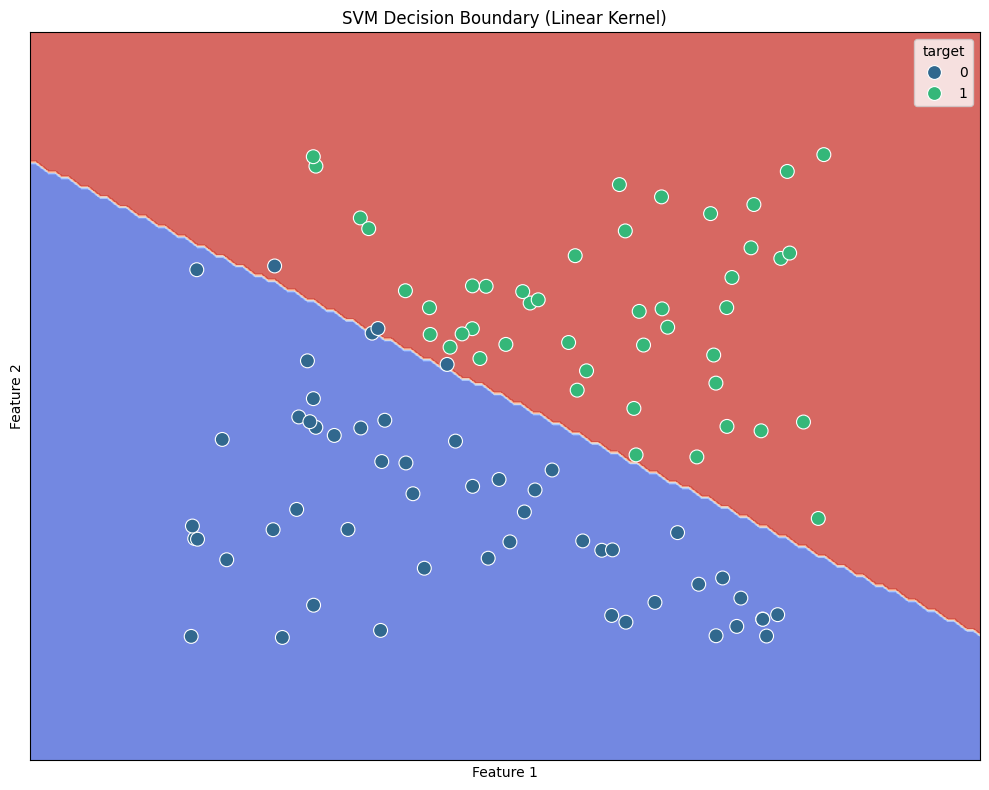

In [ ]:
import numpy as np

# Create a meshgrid to plot the decision boundary
x_min, x_max = X['feature_1'].min() - 0.5, X['feature_1'].max() + 0.5
y_min, y_max = X['feature_2'].min() - 0.5, X['feature_2'].max() + 0.5
h = 0.02  # Step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on the meshgrid points
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot the training points
sns.scatterplot(x='feature_1', y='feature_2', hue='target', data=df, palette='viridis', s=100, ax=plt.gca())

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary (Linear Kernel)')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()